# Q1: Is the number of reports within each neighborhood depending on the area of the neighborhood?
Anticipated workflow:
0. Import the packages you need to run this script.
1. Load the required datasets for processing.
2. Calculate the number of reports for each neighborhood.
3. Calculate the number of reports per area for each neighborhood.
4. Import the datasets required for plotting the final map.
5. Plot the final map. 

## 0. Import packages

In [8]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import cmcrameri.cm as cmc
from pathlib import Path

## 1. Loading the required datasets
To prepare the data for plotting, I need the spatially joined dataset and the quartiere_processed file, as it holds the area of each neighborhood.

In [9]:
def import_file(file_name): #evtl put that function to a seperate python function file! and don't forget the docstring 
    '''
    '''
    import_path=Path(f"../data/processed/{file_name}.gpkg")

    if not import_path.exists():
        print("File not found! Please check the file name and the import path.")
    return gpd.read_file(import_path)

reports_spatial=import_file("reports_quartiere_sjoin")
quartiere=import_file("quartiere_processed")

Check wheter the import worked:

In [10]:
display(quartiere.head(2))
display(reports_spatial.head(2))

,qnr,qname,knr,kname,area_km2,geometry
0,31,Alt-Wiedikon,3,Kreis 3,1.692468,"POLYGON ((2680606.662 1247034.584, 2680626.356..."
1,74,Witikon,7,Kreis 7,4.933788,"POLYGON ((2685858.632 1246502.629, 2685860.738..."


,service_request_id,requested_datetime,e,n,service_code,description,index_right,qnr,qname,knr,kname,geometry
0,1,2013-03-14 15:16:15,2678968,1247548,Strasse/Trottoir/Platz,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,16,91,Albisrieden,9,Kreis 9,POINT (2678968 1247548)
1,2,2013-03-14 15:17:57,2680746,1249916,Strasse/Trottoir/Platz,Vermessungs: Vermessungspunkt ist nicht mehr b...,20,101,Höngg,10,Kreis 10,POINT (2680746 1249916)


## 2. Calculate the number of reports for each neighborhood:
The idea is to calculate who often each "qnr" exists in the reports_spatial file. 

In [11]:
# use this code: !!!!
n_reports=(
    reports_spatial
    .groupby("qname")
    .size()
    .reset_index(name="nr_reports")#this transforms the qnr to a data column named nr_reports (after the code above it was set as the index)
    .sort_values(by="nr_reports",ascending=False) #displays me the highest values first
)
display(n_reports)

,qname,nr_reports
16,Langstrasse,6222
27,Sihlfeld,5273
3,Altstetten,4136
28,Unterstrass,3611
31,Wipkingen,3334
15,Höngg,3110
21,Oerlikon,3001
10,Hard,2880
33,Wollishofen,2861
5,Enge,2767


In [14]:
# now merge it to the quartiere dataset:
quartiere=quartiere.merge(
    n_reports,
    on="qname",
    how="left")

#quartiere=quartiere["nr_reports"]
display(quartiere.head(40))

,qnr,qname,knr,kname,area_km2,geometry,nr_reports_x,nr_reports_y
0,31,Alt-Wiedikon,3,Kreis 3,1.692468,"POLYGON ((2680606.662 1247034.584, 2680626.356...",2532,2532
1,74,Witikon,7,Kreis 7,4.933788,"POLYGON ((2685858.632 1246502.629, 2685860.738...",1142,1142
2,42,Langstrasse,4,Kreis 4,1.211798,"POLYGON ((2681313.304 1248613.857, 2681459.605...",6222,6222
3,52,Escher Wyss,5,Kreis 5,1.266279,"POLYGON ((2680009.144 1249565.021, 2680055.843...",1569,1569
4,24,Enge,2,Kreis 2,2.365206,"POLYGON ((2681898.171 1246379.668, 2681899.115...",2767,2767
5,83,Weinegg,8,Kreis 8,1.745393,"POLYGON ((2684268.476 1246568.755, 2684268.988...",815,815
6,81,Seefeld,8,Kreis 8,2.421915,"POLYGON ((2683358.477 1246403.556, 2683604.467...",1295,1295
7,23,Leimbach,2,Kreis 2,2.920166,"POLYGON ((2680272.556 1242790.921, 2680279.734...",638,638
8,21,Wollishofen,2,Kreis 2,5.780556,"POLYGON ((2681416.928 1244793.441, 2681418.119...",2861,2861
9,82,Mühlebach,8,Kreis 8,0.639116,"POLYGON ((2683784.262 1246610.465, 2683801.581...",922,922


<Axes: >

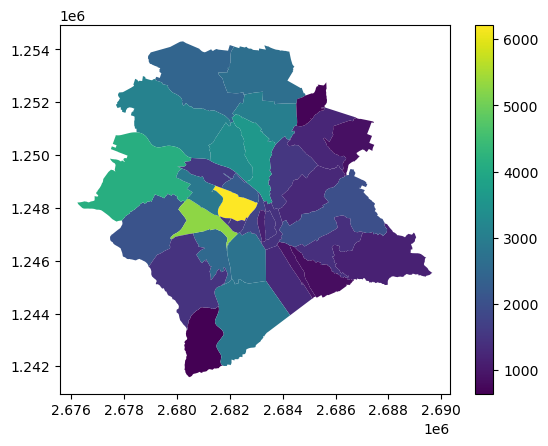

In [13]:
# quickly map this: 
fig, ax= plt.subplots()

quartiere.plot(ax=ax, column="nr_reports", legend=True)

## 3. Reports per Neighborhood Area
--> still to do